# TEMPO quickstart

This notebook follows the OQuPy quickstart setup using `quante.tensornetwork.opensystem` and compares the current `backend="mps"` result with OQuPy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import oqupy

import quante.tensornetwork.opensystem as qto
from quante.generate.matrix import pauli_matrix

## Operators and initial state

In [2]:
sigma_x = pauli_matrix("X")
sigma_z = pauli_matrix("Z")

up = pauli_matrix("u")
rho0 = up @ up.conj().T

## System, bath, and TEMPO parameters

In [3]:
Omega = 1.0
alpha = 0.3
omega_cutoff = 5.0

system = qto.System(0.5 * Omega * sigma_x)
correlation = qto.PowerLawSD(alpha=alpha, zeta=1.0, cutoff=omega_cutoff)
bath = qto.Bath(0.5 * sigma_z, correlation)
params = qto.TempoParams(dt=0.1, tcut=3.0, epsrel=1e-4)
ts = np.arange(0.0, 15.0 + params.dt / 2, params.dt)

oq_system = oqupy.System(0.5 * Omega * sigma_x)
oq_correlation = oqupy.PowerLawSD(alpha=alpha, zeta=1.0, cutoff=omega_cutoff)
oq_bath = oqupy.Bath(0.5 * sigma_z, oq_correlation)
oq_params = oqupy.TempoParameters(dt=params.dt, tcut=params.tcut, epsrel=params.epsrel)

## Correlation grid

The markers show the memory grid points implied by the TEMPO parameters. This is the `quante` equivalent of OQuPy's `plot_correlations_with_parameters` helper.

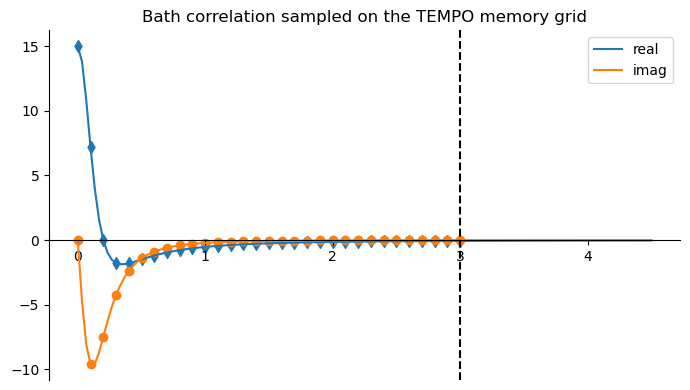

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
qto.plot_correlations_with_parameters(correlation, params, ax=ax)
ax.set_title("Bath correlation sampled on the TEMPO memory grid")
plt.tight_layout()

## Run TEMPO and compare with OQuPy

In [ ]:
times, sz = qto.tempo_compute(
    system,
    bath,
    rho0,
    ts,
    params,
    measure=0.5 * sigma_z,
    real=True,
    backend="mps",
    progressbar=True,
)

oq_dynamics = oqupy.tempo_compute(
    oq_system,
    oq_bath,
    rho0,
    0.0,
    float(ts[-1]),
    parameters=oq_params,
    # progress_type="silent",
)
oq_times, oq_sz = oq_dynamics.expectations(0.5 * sigma_z, real=True)

np.max(np.abs(sz - oq_sz))

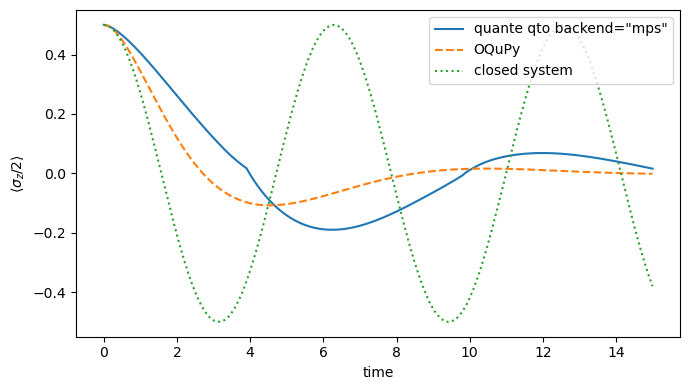

In [6]:
closed_ref = 0.5 * np.cos(Omega * times)

plt.figure(figsize=(7, 4))
plt.plot(times, sz, label='quante qto backend="mps"')
plt.plot(oq_times, oq_sz, '--', label="OQuPy")
plt.plot(times, closed_ref, ':', label="closed system")
plt.xlabel("time")
plt.ylabel(r"$\langle \sigma_z/2 \rangle$")
plt.legend()
plt.tight_layout()

## Dense reference check

The local dense `backend="reference"` is only for tiny memory lengths. It is useful for checking formulas and index order against the MPS backend.

In [7]:
short_params = qto.TempoParams(dt=0.1, tcut=0.2, epsrel=1e-8)
short_ts = np.arange(0.0, 0.3 + short_params.dt / 2, short_params.dt)

_, sz_ref = qto.tempo_compute(
    system,
    bath,
    rho0,
    short_ts,
    short_params,
    measure=0.5 * sigma_z,
    real=True,
    backend="reference",
    progressbar=False,
)
_, sz_mps_short = qto.tempo_compute(
    system,
    bath,
    rho0,
    short_ts,
    short_params,
    measure=0.5 * sigma_z,
    real=True,
    backend="mps",
    progressbar=False,
)

np.max(np.abs(sz_ref - sz_mps_short))

7.771561172376096e-16